# EDA 4CH2: Energy Surface Analysis

This notebook performs exploratory data analysis for the 4CH2 system by calculating energies across wide ranges of Jintra and deltaJ parameters and visualizing the smoothness of energy surfaces.

## Objectives
1. Calculate energies for comprehensive parameter grids
2. Visualize energy surfaces using heatmaps and contour plots
3. Analyze smoothness and identify any discontinuities
4. Create cross-sectional analysis for detailed inspection

In [3]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import ndimage
from tqdm import tqdm
import sys
import os

# Add the parent directory to the path to import nmrkan modules
if os.path.abspath(os.path.join(os.getcwd(), '..')) not in sys.path:
    sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

# Import the energy calculation function
from data_generation.eigenvalues_4CH2 import CalcEigenEnergies, get_surfaces_vectors_in_region

# Set up plotting parameters
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
sns.set_palette("viridis")

print("Libraries imported successfully!")

Libraries imported successfully!


In [70]:
deltaJ_grid, Jintra_grid, eigvals, eigvecs = get_surfaces_vectors_in_region(
    min_Jintra=-8, max_Jintra=-1, jintra_points=200,
    min_deltaJ=-32, max_deltaJ=-4, deltaJ_points=200
)

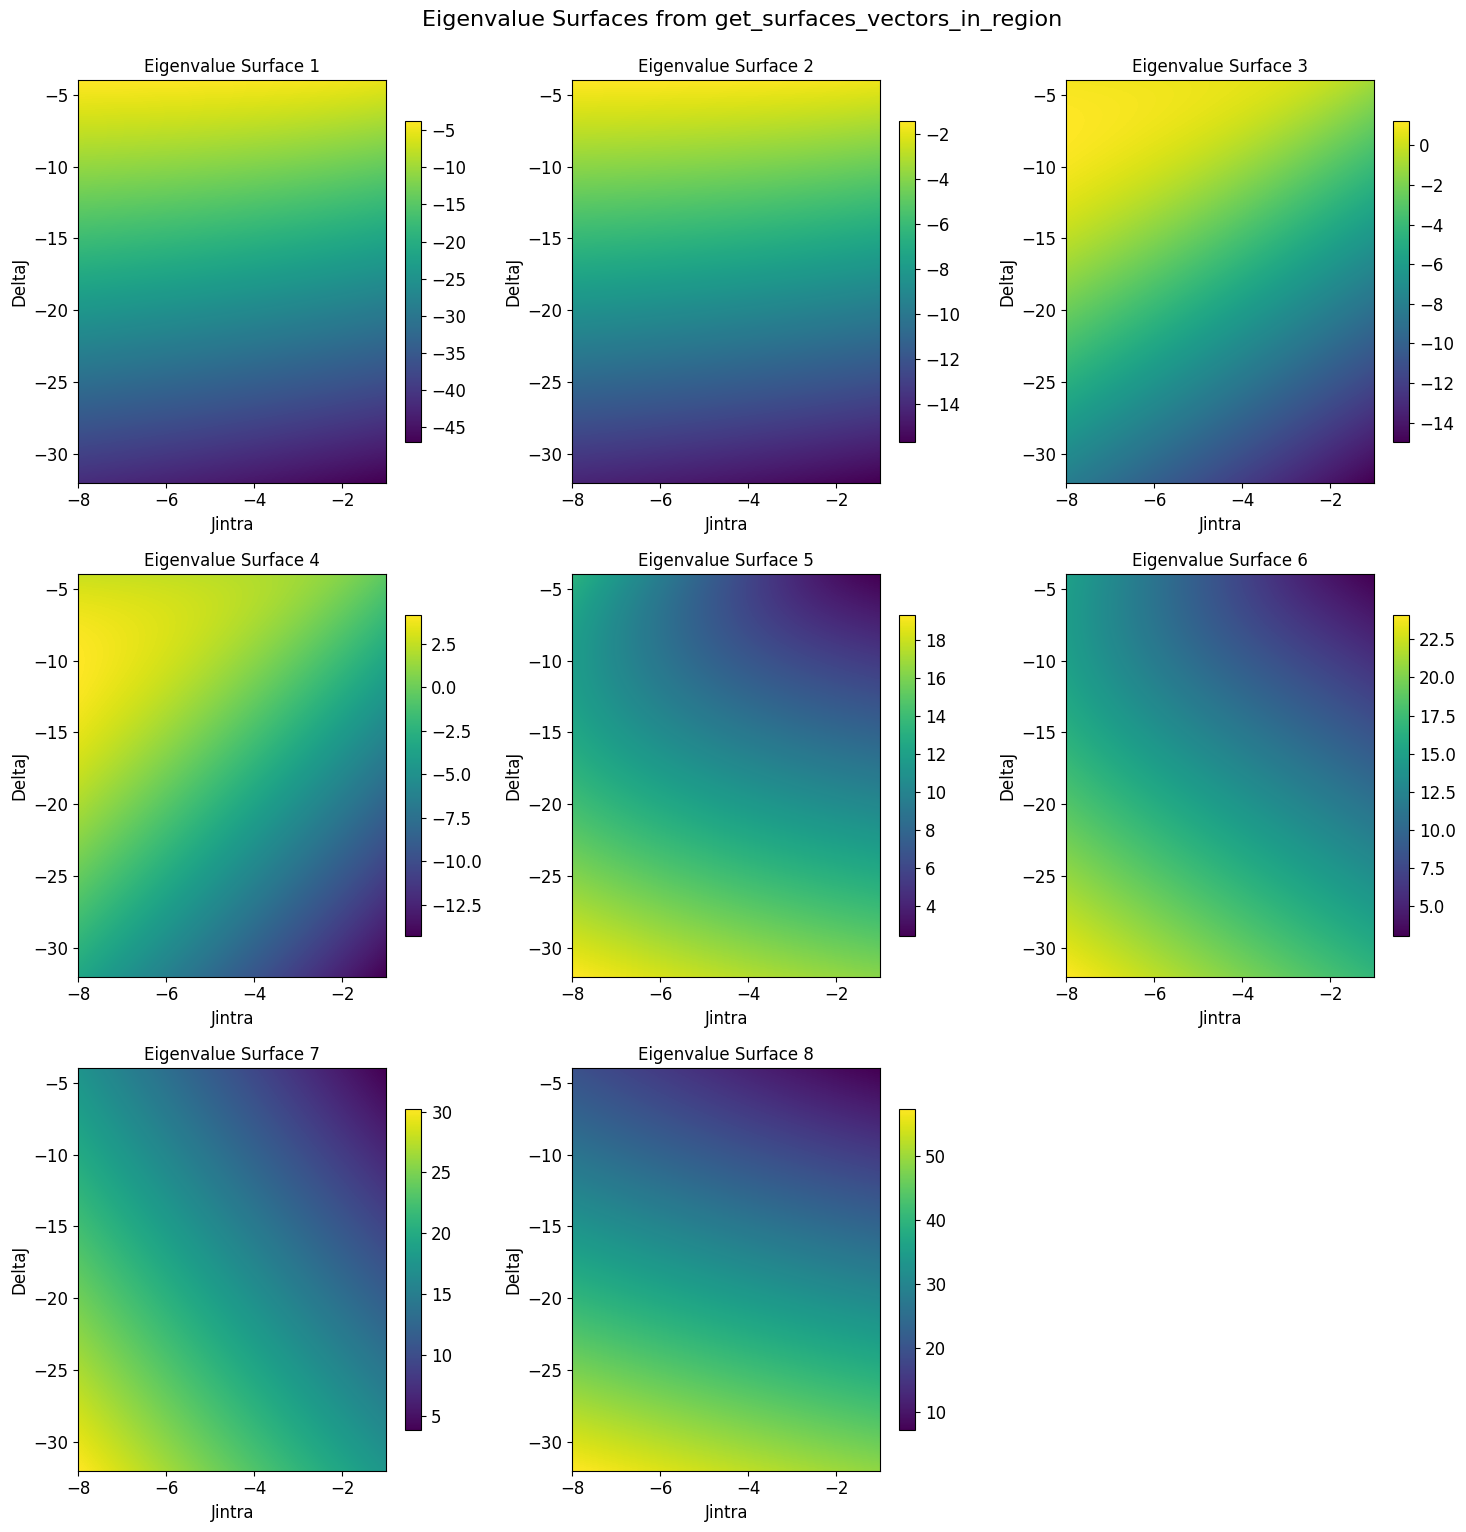

In [72]:
# plot all 8 eigenvalue surfaces in 2d on 3 x 3 subplots
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes = axes.flatten()

# Get the parameter ranges from the grids
min_Jintra, max_Jintra = Jintra_grid.min(), Jintra_grid.max()
min_deltaJ, max_deltaJ = deltaJ_grid.min(), deltaJ_grid.max()

for i in range(8):
    im = axes[i].imshow(eigvals[:, :, i], aspect='auto', origin='lower', cmap='viridis',
                       extent=[min_Jintra, max_Jintra, min_deltaJ, max_deltaJ])
    axes[i].set_title(f'Eigenvalue Surface {i+1}', fontsize=12)
    axes[i].set_xlabel('Jintra')
    axes[i].set_ylabel('DeltaJ')
    plt.colorbar(im, ax=axes[i], shrink=0.8)

# Hide the 9th subplot (since we only have 8 surfaces)
axes[8].axis('off')

plt.tight_layout()
plt.suptitle('Eigenvalue Surfaces from get_surfaces_vectors_in_region', fontsize=16, y=1.02)
plt.show()

In [75]:
deltaJ_grid_mesh, Jintra_grid_mesh = np.meshgrid(deltaJ_grid, Jintra_grid)
ratio_grid=deltaJ_grid_mesh/Jintra_grid_mesh
eigenvals_normalized = eigvals / Jintra_grid_mesh[..., np.newaxis]

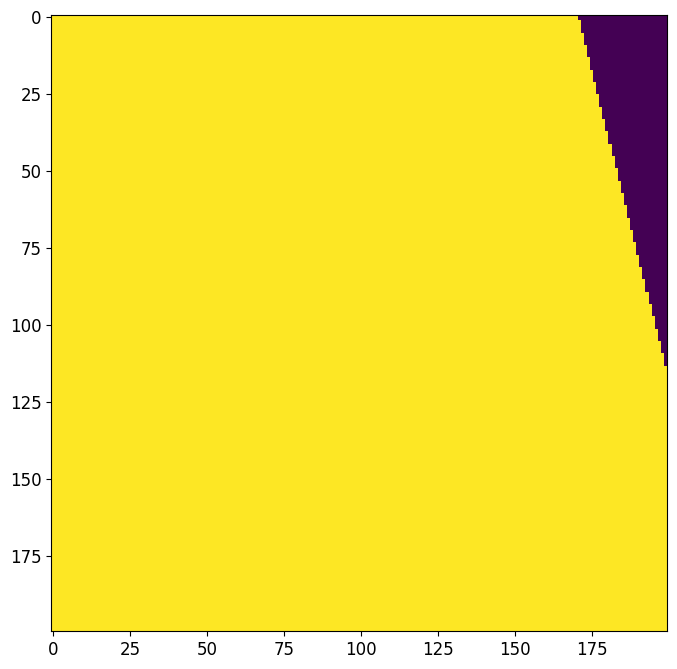

In [76]:
plt.imshow(ratio_grid>1)

In [77]:
ratio_grid.shape

(200, 200)

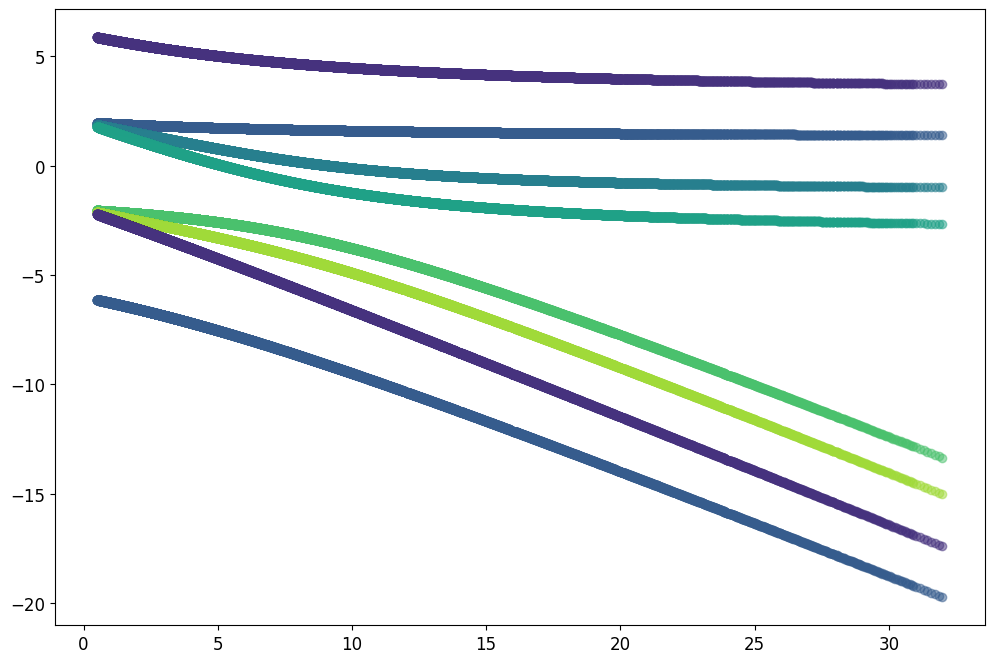

In [82]:
for i in range(8):
    plt.scatter(ratio_grid.flatten(), eigenvals_normalized[...,i].flatten(), label=f'Surface {i+1}', alpha=0.5)

In [ ]:
deltaJ_grid=
ratiogrid=deltaJ_grid/Jintra_grid

C:\Users\Alex\AppData\Local\Temp\ipykernel_17492\4025293338.py:1: RuntimeWarning: divide by zero encountered in divide
  ratiogrid=deltaJ_grid/Jintra_grid


In [11]:
deltaJ_grid.shape

(200,)

TypeError: Invalid shape (200,) for image data

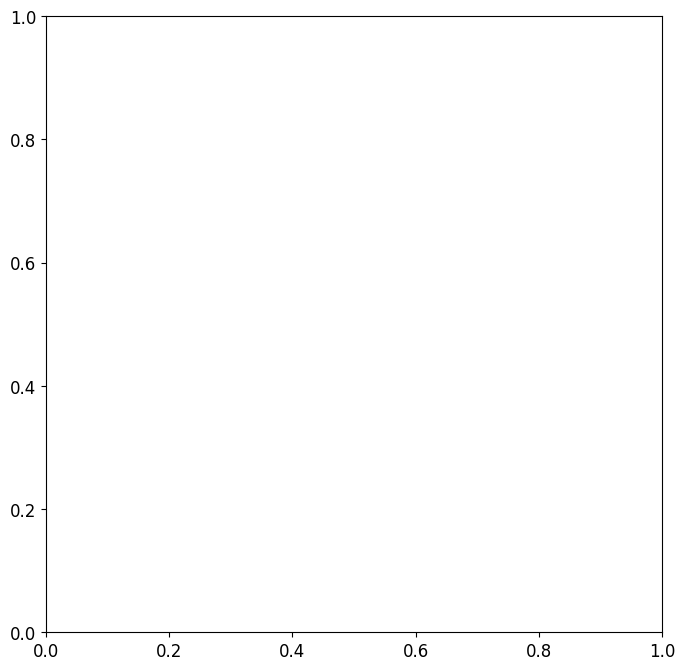

In [9]:
plt.imshow(ratiogrid)

In [43]:
# Calculate the same surfaces using CalcEigenEnergies function
print("Calculating energy surfaces using CalcEigenEnergies...")

# Define the same parameter range as used in get_surfaces_vectors_in_region
min_Jintra, max_Jintra = -32, 0
min_deltaJ, max_deltaJ = -32, 32
jintra_points = 200
deltaJ_points = 200

# Create parameter grids
deltaJ_vals = np.linspace(min_deltaJ, max_deltaJ, deltaJ_points)
Jintra_vals = np.linspace(min_Jintra, max_Jintra, jintra_points)

# Initialize array to store energy surfaces
energy_surfaces = np.zeros((deltaJ_points, jintra_points, 8))

# Calculate energies for each parameter combination
for i, deltaJ in enumerate(tqdm(deltaJ_vals, desc="Computing energy surfaces")):
    for j, Jintra in enumerate(Jintra_vals):
        energies = CalcEigenEnergies(Jintra, deltaJ)
        energy_surfaces[i, j, :] = energies

print(f"Energy surfaces calculated: {energy_surfaces.shape}")
print(f"Energy range: [{energy_surfaces.min():.3f}, {energy_surfaces.max():.3f}]")

Calculating energy surfaces using CalcEigenEnergies...


Computing energy surfaces: 100%|██████████| 200/200 [00:01<00:00, 101.72it/s]

Energy surfaces calculated: (200, 200, 8)
Energy range: [-48.000, 97.027]


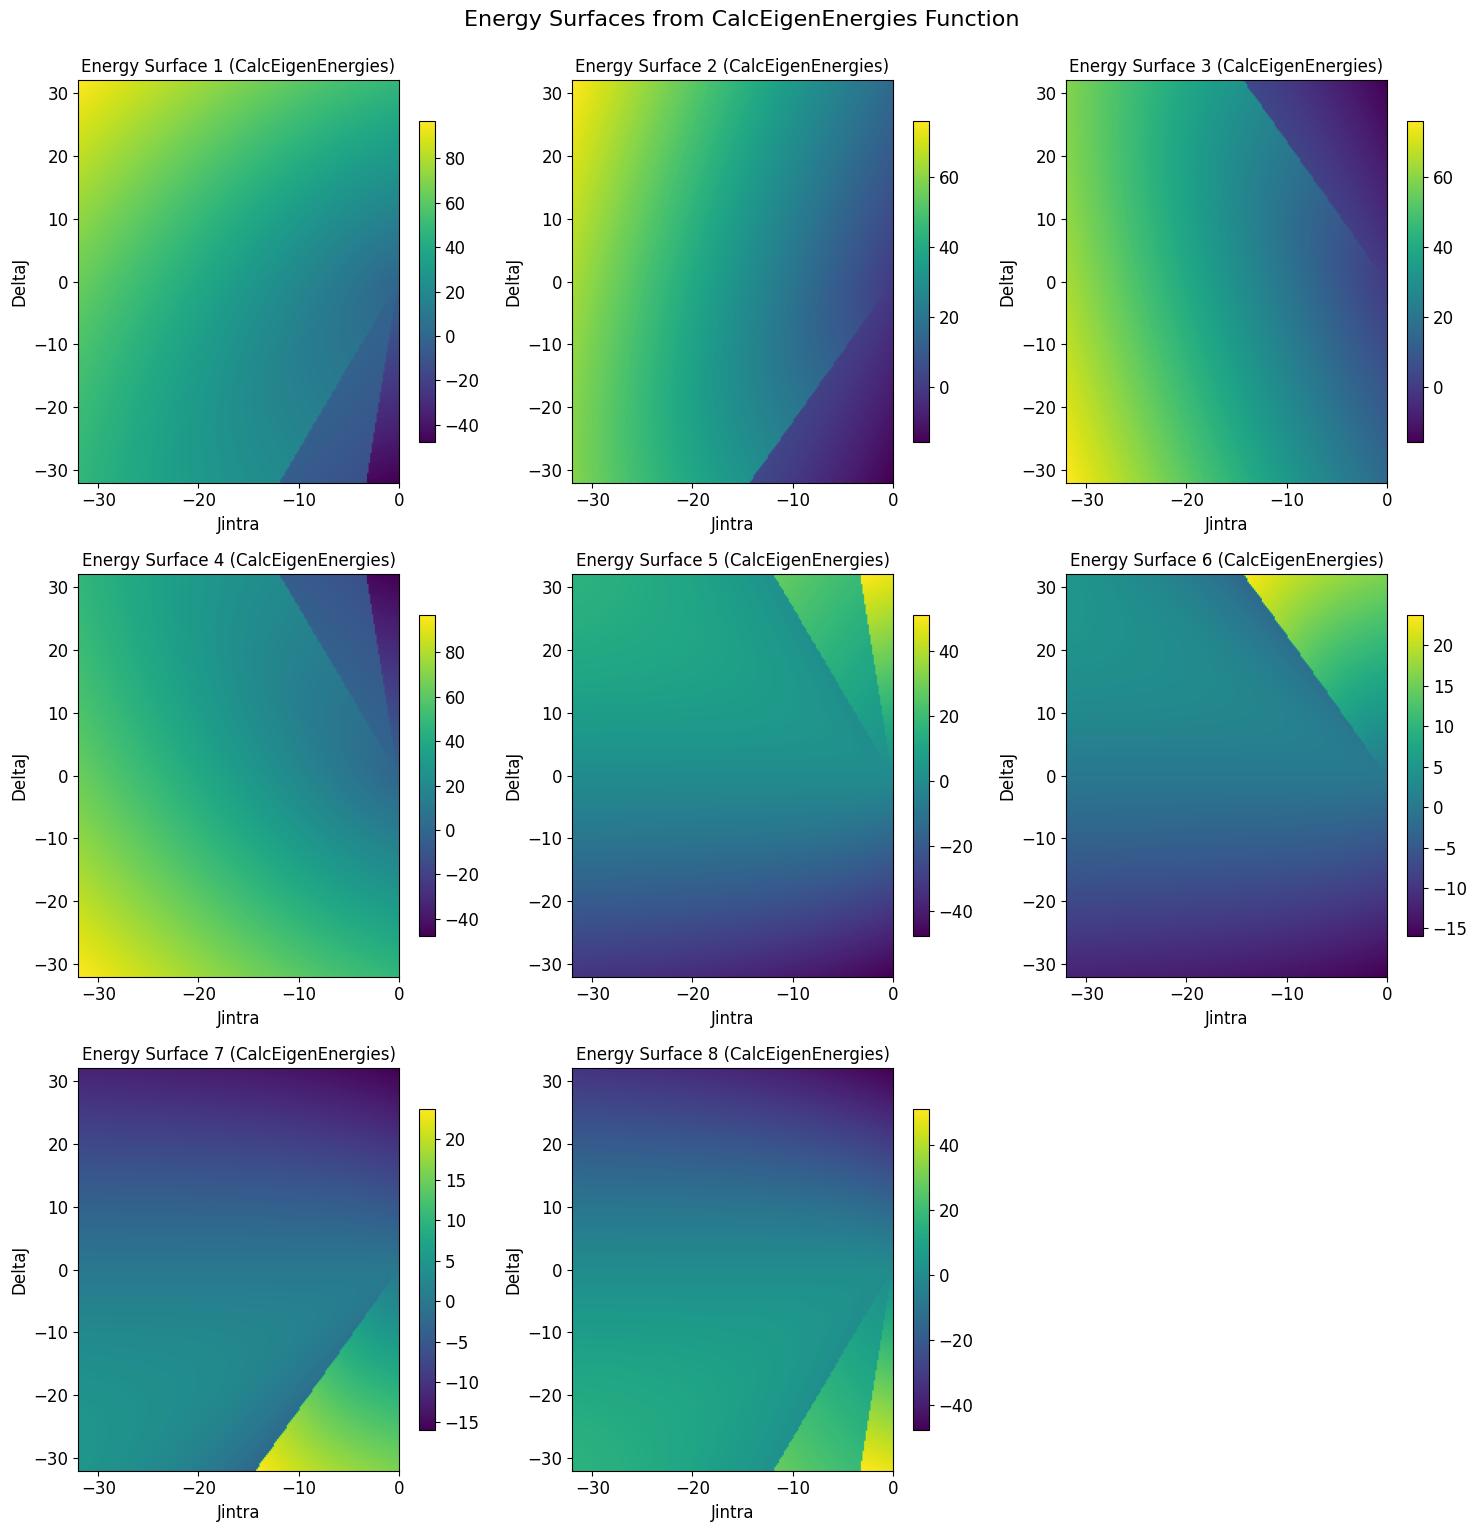

In [44]:
# Plot all 8 energy surfaces in 2D on 3x3 subplots (using CalcEigenEnergies)
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes = axes.flatten()

for i in range(8):
    im = axes[i].imshow(energy_surfaces[:, :, i], aspect='auto', origin='lower', cmap='viridis',
                       extent=[min_Jintra, max_Jintra, min_deltaJ, max_deltaJ])
    axes[i].set_title(f'Energy Surface {i+1} (CalcEigenEnergies)', fontsize=12)
    axes[i].set_xlabel('Jintra')
    axes[i].set_ylabel('DeltaJ')
    plt.colorbar(im, ax=axes[i], shrink=0.8)

# Hide the 9th subplot (since we only have 8 surfaces)
axes[8].axis('off')

plt.tight_layout()
plt.suptitle('Energy Surfaces from CalcEigenEnergies Function', fontsize=16, y=1.02)
plt.show()

In [ ]:
# get correspondences:
corrindices = np.ones(8, dtype=int)*1000000
select = np.zeros(8, dtype=int)
for i in range(8):
    for j in range(8):
        diff = np.abs(eigvals[:, :, i] - energy_surfaces[:, :, j])
        median_diff = np.median(diff)
        if median_diff < corrindices[i]:
            corrindices[i] = median_diff
            select[i] = j

In [ ]:
select

array([4, 5, 6, 7, 0, 1, 2, 3])